# Level 1 · Task 2 — Simple Linear Regression (House Prices)

**Goal:** build a linear regression model that predicts house prices (`MEDV`,
median value in $1000s) from the Boston Housing dataset.

**Steps:**
1. Load & explore the data
2. Preprocess + quick EDA
3. Train linear regression (single feature *and* all features)
4. Interpret the coefficients
5. Evaluate with **R-squared** and **MSE**

*Tools: Python, pandas, scikit-learn, matplotlib*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 30)

# the file is space-separated and has no header, so we supply the
# classic Boston Housing column names ourselves
COLUMNS = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
           'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

df = pd.read_csv('../data/house_prediction.csv', sep=r'\s+', header=None, names=COLUMNS)
print('shape:', df.shape)
df.head()

shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [2]:
# quick sanity check — types, missing values, basic stats
print(df.dtypes.value_counts())
print('\nmissing values:', df.isna().sum().sum())
df.describe().round(2)

float64    12
int64       2
Name: count, dtype: int64

missing values: 0


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


## Step 1 — Preprocess & quick EDA

The data is clean (no missing values, all numeric), so preprocessing is light.
Let's look at the target distribution and see which features correlate with price.

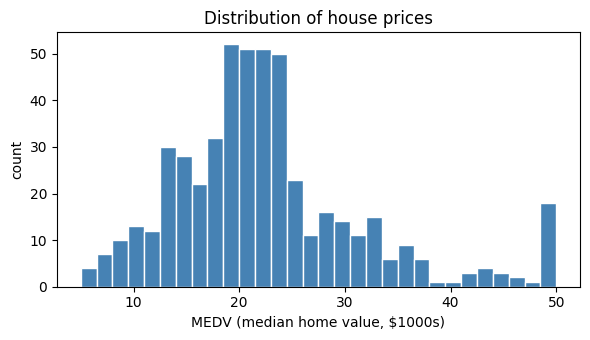

In [3]:
# target distribution
plt.figure(figsize=(6, 3.5))
plt.hist(df['MEDV'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('MEDV (median home value, $1000s)')
plt.ylabel('count')
plt.title('Distribution of house prices')
plt.tight_layout()
plt.show()

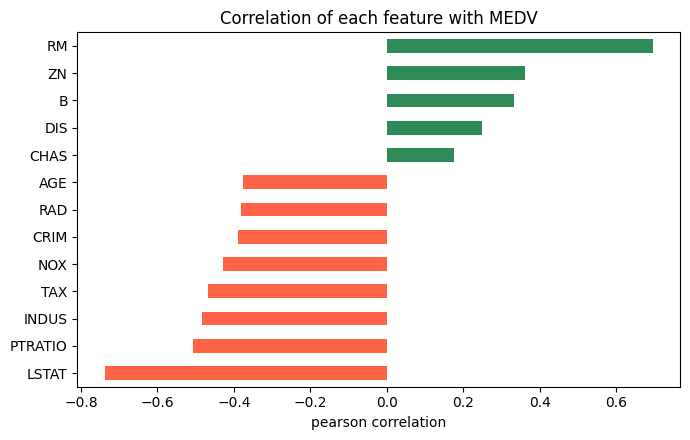

strongest positive: RM 0.7
strongest negative: LSTAT -0.74


In [4]:
# which features move the price?
corr = df.corr()['MEDV'].drop('MEDV').sort_values()

plt.figure(figsize=(7, 4.5))
colors = ['tomato' if c < 0 else 'seagreen' for c in corr]
corr.plot(kind='barh', color=colors)
plt.title('Correlation of each feature with MEDV')
plt.xlabel('pearson correlation')
plt.tight_layout()
plt.show()

print('strongest positive:', corr.idxmax(), round(corr.max(), 2))
print('strongest negative:', corr.idxmin(), round(corr.min(), 2))

**Reading:** `RM` (average rooms per dwelling) has the strongest **positive**
link with price, while `LSTAT` (% lower-status population) has the strongest
**negative** link. A full correlation heatmap for completeness:

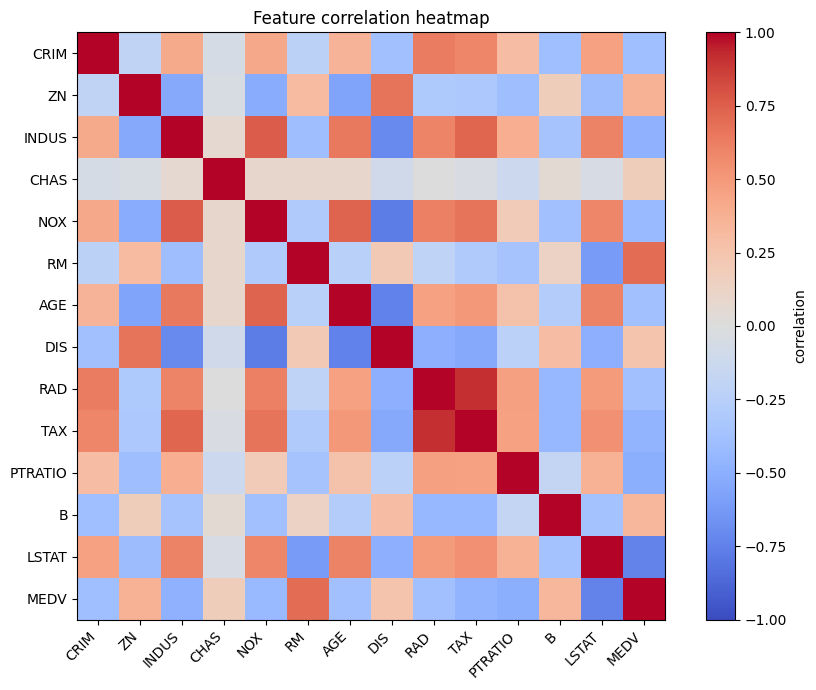

In [5]:
plt.figure(figsize=(9, 7))
c = df.corr()
plt.imshow(c, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='correlation')
plt.xticks(range(len(c.columns)), c.columns, rotation=45, ha='right')
plt.yticks(range(len(c.columns)), c.columns)
plt.title('Feature correlation heatmap')
plt.tight_layout()
plt.show()